In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings(action='ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [9]:
df=pd.read_csv(r"C:\Users\mahar\OneDrive\Pictures\문서\All Data sets\wine_clean.csv")

In [11]:
df

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [13]:
df.shape

(178, 14)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_Acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_Ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_Phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_Phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_Intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [17]:
df.describe()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [19]:
df.isnull().sum()

Class                   0
Alcohol                 0
Malic_Acid              0
Ash                     0
Alcalinity_of_Ash       0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64

In [21]:
df.duplicated().sum()

0

In [23]:
x=df.drop(columns='Class')
y=df['Class']

In [25]:
y.head(2)

0    1
1    1
Name: Class, dtype: int64

In [27]:
x.shape

(178, 13)

In [29]:
y.shape

(178,)

In [31]:
np.unique(y)

array([1, 2, 3], dtype=int64)

In [33]:
# Train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)

In [35]:
# Feature Scaling
scaler=StandardScaler()

In [37]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [41]:
#Build Knn model

knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [43]:
y_pred=knn.predict(x_test_scaled)
y_pred

array([2, 3, 1, 2, 3, 3, 2, 2, 2, 2, 3, 1, 3, 3, 3, 1, 3, 1, 2, 1, 3, 1,
       2, 2, 1, 1, 2, 2, 2, 3, 3, 2, 1, 2, 3, 3], dtype=int64)

In [45]:
Comparsion=pd.DataFrame({'y_test':y_test,'y_pred':y_pred})
Comparsion

,y_test,y_pred
88,2,2
159,3,3
11,1,1
74,2,2
158,3,3
149,3,3
99,2,2
96,2,2
90,2,2
95,2,2


In [47]:
y_test

88     2
159    3
11     1
74     2
158    3
149    3
99     2
96     2
90     2
95     2
134    3
65     2
171    3
165    3
169    3
15     1
145    3
7      1
77     2
41     1
150    3
32     1
118    2
92     2
40     1
1      1
75     2
114    2
64     2
163    3
147    3
69     2
26     1
97     2
146    3
151    3
Name: Class, dtype: int64

In [49]:
accuracy_score(y_test,y_pred)

0.9722222222222222

In [51]:
confusion_matrix=confusion_matrix(y_test,y_pred)
print(confusion_matrix)

[[ 8  0  0]
 [ 1 14  0]
 [ 0  0 13]]


In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.89      1.00      0.94         8
           2       1.00      0.93      0.97        15
           3       1.00      1.00      1.00        13

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



In [55]:
accuracy_list=[]
for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled,y_train)
    predication=model.predict(x_test_scaled)
    score=accuracy_score(y_test,y_pred)
    accuracy_list.append(score)
    print('k',k,'Accuracy=',score)

k 1 Accuracy= 0.9722222222222222
k 2 Accuracy= 0.9722222222222222
k 3 Accuracy= 0.9722222222222222
k 4 Accuracy= 0.9722222222222222
k 5 Accuracy= 0.9722222222222222
k 6 Accuracy= 0.9722222222222222
k 7 Accuracy= 0.9722222222222222
k 8 Accuracy= 0.9722222222222222
k 9 Accuracy= 0.9722222222222222
k 10 Accuracy= 0.9722222222222222
k 11 Accuracy= 0.9722222222222222
k 12 Accuracy= 0.9722222222222222
k 13 Accuracy= 0.9722222222222222
k 14 Accuracy= 0.9722222222222222
k 15 Accuracy= 0.9722222222222222
k 16 Accuracy= 0.9722222222222222
k 17 Accuracy= 0.9722222222222222
k 18 Accuracy= 0.9722222222222222
k 19 Accuracy= 0.9722222222222222
k 20 Accuracy= 0.9722222222222222


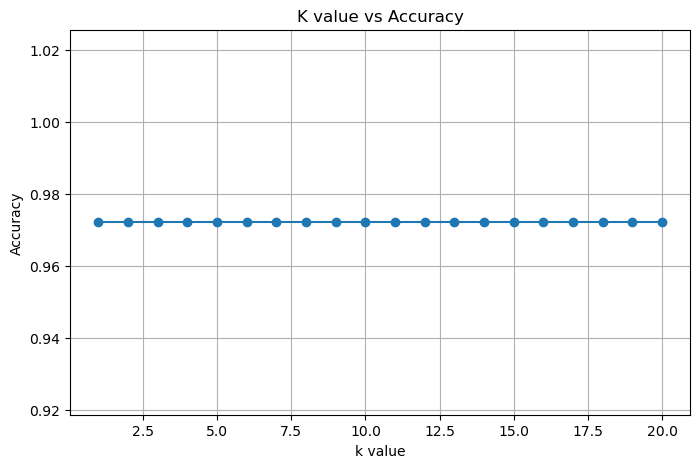

In [57]:
plt.figure(figsize=(8,5))
plt.plot(range(1,21),accuracy_list,marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('K value vs Accuracy')
plt.grid()

In [59]:
#Find best K

best_k=np.argmax(accuracy_list)+1
print(best_k)

1


In [63]:
df.head(1)

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065


In [67]:
sample=[[13.32,3.22,2.5,17.3,150,1.7,2.67,1.2,2.4,4.67,2.3,1.29,1500]]
sample=scaler.fit_transform(sample)
predication=model.predict(sample)
print(predication)

[1]
